# Study on the market credit spread

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use('seaborn-v0_8-whitegrid')
example_root = Path(os.path.abspath(""))

## Data loading

In [2]:
eurirs_df   = pd.read_csv(example_root / "data" / f"EURIRS_history_2000-01-01_to_2025-12-31.csv")
ftse_AAA_df = pd.read_csv(example_root / "data" / f"FTEBIG_3AEURT_2000-01-01_to_2025-12-31.csv")
ftse_AA_df  = pd.read_csv(example_root / "data" / f"FTEBIG_2AEURT_2000-01-01_to_2025-12-31.csv")
ftse_A_df   = pd.read_csv(example_root / "data" / f"FTEBIG_1AEURT_2000-01-01_to_2025-12-31.csv")
ftse_BBB_df = pd.read_csv(example_root / "data" / f"FTEBIG_3BEURT_2000-01-01_to_2025-12-31.csv")
ftse_HY_df  = pd.read_csv(example_root / "data" / f"FTEHYM_EUREURT_2000-01-01_to_2025-12-31.csv")
itraxx_df   = pd.read_csv(example_root / "data" / f"ITEEU5Y=_2000-01-01_to_2025-12-31.csv")

In [3]:
colors = ["indianred",
          "royalblue",
          "forestgreen",
          "dimgrey"]

## FTSE EURO BROAD INVESTMENT-GRADE BOND AAA TOTAL RETURN INDEX

In [4]:
ftse_AAA_avg_dur = round(ftse_AAA_df["MAC_DURTN"].mean())
ftse_AAA_ts_df   = pd.merge(ftse_AAA_df, eurirs_df[["Date", f"{int(ftse_AAA_avg_dur)}Y"]], how='left', left_on='Date', right_on='Date')
ftse_AAA_ts_df   = pd.merge(ftse_AAA_ts_df, itraxx_df, how='left', left_on='Date', right_on='Date')
ftse_AAA_ts_df   = ftse_AAA_ts_df[["Date", "YLDTOMAT", f"{int(ftse_AAA_avg_dur)}Y", "MID_SPREAD"]]
ftse_AAA_ts_df.dropna(inplace=True)
ftse_AAA_ts_df.columns = ["Date", "FTSE_AAA_YTM", f"EURIRS_{int(ftse_AAA_avg_dur)}Y", "ITRAXX_EUROPE_MID_SPREAD"]
ftse_AAA_ts_df["ITRAXX_EUROPE_MID_SPREAD"] = ftse_AAA_ts_df["ITRAXX_EUROPE_MID_SPREAD"] / 100

In [5]:
ftse_AAA_ts_df.head()

,Date,FTSE_AAA_YTM,EURIRS_6Y,ITRAXX_EUROPE_MID_SPREAD
6056,2023-10-10,3.1868,3.303,0.848750
6057,2023-10-11,3.1668,3.281,0.830250
6060,2023-10-16,3.2242,3.334,0.816200
6061,2023-10-17,3.3008,3.420,0.836250
6062,2023-10-18,3.3360,3.450,0.845775


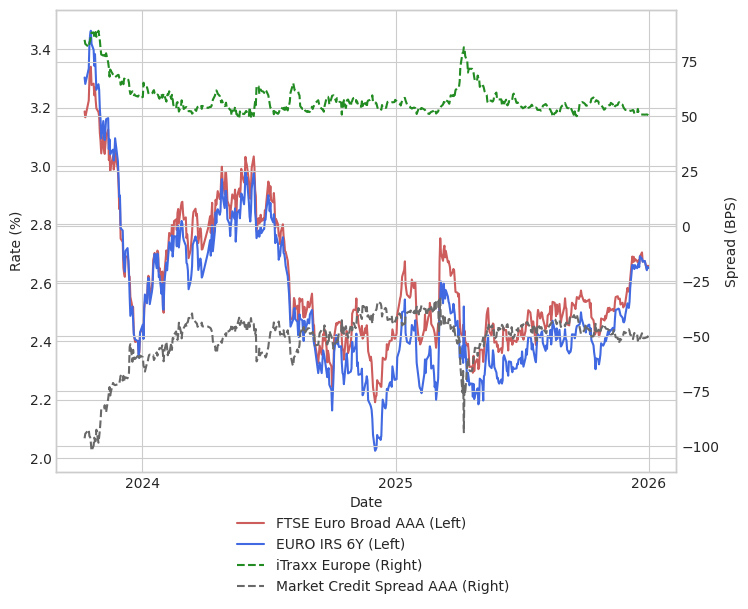

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

twinx = ax.twinx()

dates     = pd.DatetimeIndex(ftse_AAA_ts_df["Date"])
market_cs = ftse_AAA_ts_df["FTSE_AAA_YTM"] - ftse_AAA_ts_df[f"EURIRS_{int(ftse_AAA_avg_dur)}Y"] - ftse_AAA_ts_df["ITRAXX_EUROPE_MID_SPREAD"]

plot1, = ax.plot(dates, ftse_AAA_ts_df["FTSE_AAA_YTM"], color=colors[0], label="FTSE Euro Broad AAA (Left)")
plot2, = ax.plot(dates, ftse_AAA_ts_df[f"EURIRS_{int(ftse_AAA_avg_dur)}Y"], color=colors[1], label=f"EURO IRS {int(ftse_AAA_avg_dur)}Y (Left)")

plot3, = twinx.plot(dates, ftse_AAA_ts_df["ITRAXX_EUROPE_MID_SPREAD"] * 100, linestyle="dashed", color=colors[2], label="iTraxx Europe (Right)")
plot4, = twinx.plot(dates, market_cs * 100, color=colors[3], linestyle="dashed", label="Market Credit Spread AAA (Right)")

ax.legend(handles=[plot1, plot2, plot3, plot4], bbox_to_anchor=(0.75, -0.07), fancybox=True, ncol=1)

ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
twinx.set_ylabel("Spread (BPS)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

In [7]:
print(f"Mean market credit spread: {(market_cs.mean() * 100):.2f} BPS")

Mean market credit spread: -50.69 BPS


## FTSE EURO BROAD INVESTMENT-GRADE BOND BBB TOTAL RETURN INDEX

In [8]:
ftse_BBB_avg_dur = round(ftse_BBB_df["MAC_DURTN"].mean())
ftse_BBB_ts_df   = pd.merge(ftse_BBB_df, eurirs_df[["Date", f"{int(ftse_BBB_avg_dur)}Y"]], how='left', left_on='Date', right_on='Date')
ftse_BBB_ts_df   = pd.merge(ftse_BBB_ts_df, itraxx_df, how='left', left_on='Date', right_on='Date')
ftse_BBB_ts_df   = ftse_BBB_ts_df[["Date", "YLDTOMAT", f"{int(ftse_BBB_avg_dur)}Y", "MID_SPREAD"]]
ftse_BBB_ts_df.dropna(inplace=True)
ftse_BBB_ts_df.columns = ["Date", "FTSE_BBB_YTM", f"EURIRS_{int(ftse_BBB_avg_dur)}Y", "ITRAXX_EUROPE_MID_SPREAD"]
ftse_BBB_ts_df["ITRAXX_EUROPE_MID_SPREAD"] = ftse_BBB_ts_df["ITRAXX_EUROPE_MID_SPREAD"] / 100

In [9]:
ftse_BBB_ts_df.head()

,Date,FTSE_BBB_YTM,EURIRS_5Y,ITRAXX_EUROPE_MID_SPREAD
6057,2023-10-10,4.5543,3.319,0.848750
6058,2023-10-11,4.5177,3.311,0.830250
6061,2023-10-16,4.5755,3.360,0.816200
6062,2023-10-17,4.6661,3.446,0.836250
6063,2023-10-18,4.7273,3.474,0.845775


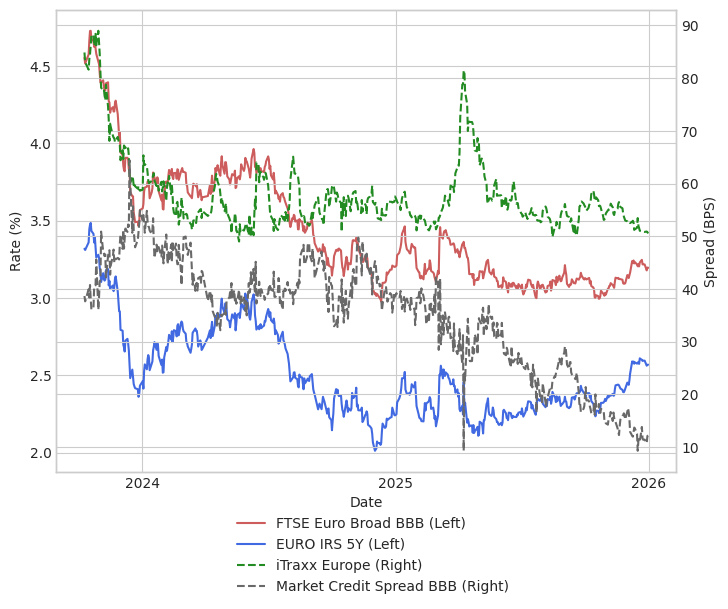

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

twinx = ax.twinx()

dates     = pd.DatetimeIndex(ftse_BBB_ts_df["Date"])
market_cs = ftse_BBB_ts_df["FTSE_BBB_YTM"] - ftse_BBB_ts_df[f"EURIRS_{int(ftse_BBB_avg_dur)}Y"] - ftse_BBB_ts_df["ITRAXX_EUROPE_MID_SPREAD"]

plot1, = ax.plot(dates, ftse_BBB_ts_df["FTSE_BBB_YTM"], color=colors[0], label="FTSE Euro Broad BBB (Left)")
plot2, = ax.plot(dates, ftse_BBB_ts_df[f"EURIRS_{int(ftse_BBB_avg_dur)}Y"], color=colors[1], label=f"EURO IRS {int(ftse_BBB_avg_dur)}Y (Left)")

plot3, = twinx.plot(dates, ftse_BBB_ts_df["ITRAXX_EUROPE_MID_SPREAD"] * 100, linestyle="dashed", color=colors[2], label="iTraxx Europe (Right)")
plot4, = twinx.plot(dates, market_cs * 100, color=colors[3], linestyle="dashed", label="Market Credit Spread BBB (Right)")

ax.legend(handles=[plot1, plot2, plot3, plot4], bbox_to_anchor=(0.75, -0.07), fancybox=True, ncol=1)

ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
twinx.set_ylabel("Spread (BPS)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

In [11]:
print(f"Mean market credit spread: {(market_cs.mean() * 100):.2f} BPS")

Mean market credit spread: 34.90 BPS


## FTSE EURO HIGH-YIELD BOND TOTAL RETURN INDEX

In [12]:
ftse_HY_avg_dur = round(ftse_HY_df["MAC_DURTN"].mean())
ftse_HY_ts_df   = pd.merge(ftse_HY_df, eurirs_df[["Date", f"{int(ftse_HY_avg_dur)}Y"]], how='left', left_on='Date', right_on='Date')
ftse_HY_ts_df   = pd.merge(ftse_HY_ts_df, itraxx_df, how='left', left_on='Date', right_on='Date')
ftse_HY_ts_df   = ftse_HY_ts_df[["Date", "YLDTOMAT", f"{int(ftse_HY_avg_dur)}Y", "MID_SPREAD"]]
ftse_HY_ts_df.dropna(inplace=True)
ftse_HY_ts_df.columns = ["Date", "FTSE_HY_YTM", f"EURIRS_{int(ftse_HY_avg_dur)}Y", "ITRAXX_EUROPE_MID_SPREAD"]
ftse_HY_ts_df["ITRAXX_EUROPE_MID_SPREAD"] = ftse_HY_ts_df["ITRAXX_EUROPE_MID_SPREAD"] / 100

In [13]:
ftse_HY_ts_df.head()

,Date,FTSE_HY_YTM,EURIRS_3Y,ITRAXX_EUROPE_MID_SPREAD
43,2023-10-09,8.1654,3.458,0.86390
44,2023-10-10,8.0930,3.469,0.84875
45,2023-10-11,8.0159,3.490,0.83025
48,2023-10-16,8.0587,3.534,0.81620
49,2023-10-17,8.1291,3.613,0.83625


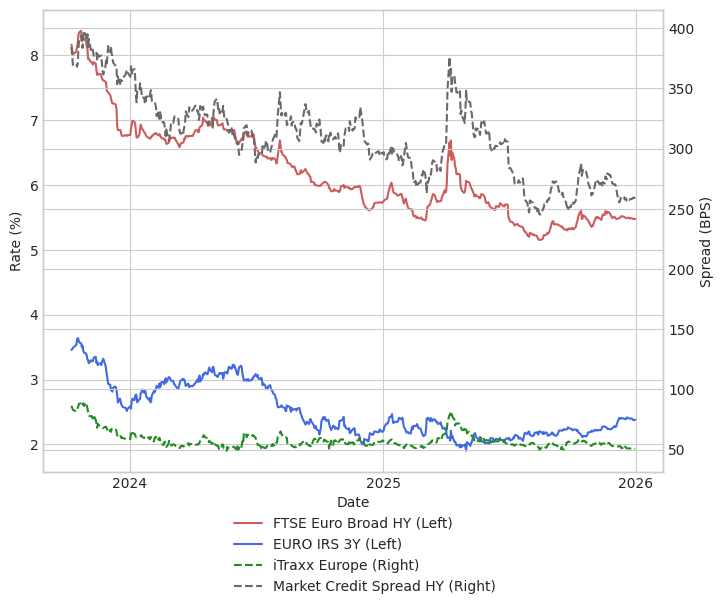

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

twinx = ax.twinx()

dates     = pd.DatetimeIndex(ftse_HY_ts_df["Date"])
market_cs = ftse_HY_ts_df["FTSE_HY_YTM"] - ftse_HY_ts_df[f"EURIRS_{int(ftse_HY_avg_dur)}Y"] - ftse_HY_ts_df["ITRAXX_EUROPE_MID_SPREAD"]

plot1, = ax.plot(dates, ftse_HY_ts_df["FTSE_HY_YTM"], color=colors[0], label="FTSE Euro Broad HY (Left)")
plot2, = ax.plot(dates, ftse_HY_ts_df[f"EURIRS_{int(ftse_HY_avg_dur)}Y"], color=colors[1], label=f"EURO IRS {int(ftse_HY_avg_dur)}Y (Left)")

plot3, = twinx.plot(dates, ftse_HY_ts_df["ITRAXX_EUROPE_MID_SPREAD"] * 100, linestyle="dashed", color=colors[2], label="iTraxx Europe (Right)")
plot4, = twinx.plot(dates, market_cs * 100, color=colors[3], linestyle="dashed", label="Market Credit Spread HY (Right)")

ax.legend(handles=[plot1, plot2, plot3, plot4], bbox_to_anchor=(0.75, -0.07), fancybox=True, ncol=1)

ax.set_xlabel("Date")
ax.set_ylabel("Rate (%)")
twinx.set_ylabel("Spread (BPS)")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.show()

In [15]:
print(f"Mean market credit spread: {(market_cs.mean() * 100):.2f} BPS")

Mean market credit spread: 309.05 BPS
